In [1]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import easysnowdata
import numpy as np
import rasterio
import os
import contextily as ctx
import shutil


DATA_DIR = Path("data/NorSWE")
NORSWE_ZARR_FILEPATH = DATA_DIR / "NorSWE.zarr"

MAX_NORSWE_TIMING_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/max_NorSWE_swe_timing.zarr')
RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/runoff_onset_NorSWE_station_chips.zarr')

In [2]:
NorSWE_ds = xr.open_dataset(NORSWE_ZARR_FILEPATH)
NorSWE_ds

<xarray.Dataset> Size: 3GB
Dimensions:        (time: 15706, station_id: 10153)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
  * station_id     (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    elevation      (station_id) float32 41kB ...
    latitude       (station_id) float32 41kB ...
    longitude      (station_id) float32 41kB ...
    mmask          (station_id) uint8 10kB ...
    source         (station_id) <U63 3MB ...
    station_name   (station_id) <U63 3MB ...
    type_mes       (station_id) uint8 10kB ...
Data variables:
    data_flag_snd  (time, station_id) int8 159MB ...
    data_flag_snw  (time, station_id) int8 159MB ...
    den            (time, station_id) float32 638MB ...
    qc_flag_snd    (time, station_id) int8 159MB ...
    qc_flag_snw    (time, station_id) int8 159MB ...
    snd            (time, station_id) float32 638MB ...
    snw            (time, station_id) float32 638MB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [3]:
# clip NorSWE dataset to high mountain asia, have to use latitude and longitude because the NorSWE dataset is not in a projected coordinate system
NorSWE_ds.where((NorSWE_ds.latitude >= 25) & (NorSWE_ds.latitude <= 45) & (NorSWE_ds.longitude >= 70) & (NorSWE_ds.longitude <= 105), drop=True)
NorSWE_ds.sel(station_id='NVE-1977.1.4')

<xarray.Dataset> Size: 378kB
Dimensions:        (time: 15706)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
    elevation      float32 4B ...
    latitude       float32 4B 28.15
    longitude      float32 4B 85.56
    mmask          uint8 1B ...
    source         <U63 252B ...
    station_id     <U32 128B 'NVE-1977.1.4'
    station_name   <U63 252B ...
    type_mes       uint8 1B ...
Data variables:
    data_flag_snd  (time) int8 16kB ...
    data_flag_snw  (time) int8 16kB ...
    den            (time) float32 63kB ...
    qc_flag_snd    (time) int8 16kB ...
    qc_flag_snw    (time) int8 16kB ...
    snd            (time) float32 63kB ...
    snw            (time) float32 63kB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [4]:
NorSWE_ds.coords['water_year'] = ("time", pd.to_datetime(NorSWE_ds['time']).map(easysnowdata.utils.datetime_to_WY))
NorSWE_ds.coords['DOWY'] = ("time", pd.to_datetime(NorSWE_ds['time']).map(easysnowdata.utils.datetime_to_DOWY))
NorSWE_ds

<xarray.Dataset> Size: 3GB
Dimensions:        (time: 15706, station_id: 10153)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
    water_year     (time) int64 126kB 1979 1979 1979 1979 ... 2022 2022 2022
    DOWY           (time) int64 126kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
  * station_id     (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    elevation      (station_id) float32 41kB ...
    latitude       (station_id) float32 41kB 49.27 49.82 49.25 ... 61.95 61.16
    longitude      (station_id) float32 41kB -114.3 -114.6 ... 10.09 10.71
    mmask          (station_id) uint8 10kB ...
    source         (station_id) <U63 3MB ...
    station_name   (station_id) <U63 3MB ...
    type_mes       (station_id) uint8 10kB ...
Data variables:
    data_flag_snd  (time, station_id) int8 159MB ...
    data_flag_snw  (time, station_id) int8 159MB ...
    den            (time, station_id) float32 638MB ...
    qc_flag_snd    (time, station_id) int8 159MB ...
    qc_flag_snw    (time, station_id) int8 159MB ...
    snd            (time, station_id) float32 638MB ...
    snw            (time, station_id) float32 638MB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [5]:
# filter just to water years 2015-2024, use coordinate WY
NorSWE_ds = NorSWE_ds.sel(time=NorSWE_ds['water_year'].isin([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]))
#remove WY 2022 because it is incomplete
NorSWE_ds = NorSWE_ds.sel(time=~NorSWE_ds['water_year'].isin([2022]))
NorSWE_ds

<xarray.Dataset> Size: 422MB
Dimensions:        (time: 2557, station_id: 10153)
Coordinates:
  * time           (time) datetime64[ns] 20kB 2014-10-01 ... 2021-09-30
    water_year     (time) int64 20kB 2015 2015 2015 2015 ... 2021 2021 2021 2021
    DOWY           (time) int64 20kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * station_id     (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    elevation      (station_id) float32 41kB ...
    latitude       (station_id) float32 41kB 49.27 49.82 49.25 ... 61.95 61.16
    longitude      (station_id) float32 41kB -114.3 -114.6 ... 10.09 10.71
    mmask          (station_id) uint8 10kB ...
    source         (station_id) <U63 3MB ...
    station_name   (station_id) <U63 3MB ...
    type_mes       (station_id) uint8 10kB ...
Data variables:
    data_flag_snd  (time, station_id) int8 26MB ...
    data_flag_snw  (time, station_id) int8 26MB ...
    den            (time, station_id) float32 104MB ...
    qc_flag_snd    (time, station_id) int8 26MB ...
    qc_flag_snw    (time, station_id) int8 26MB ...
    snd            (time, station_id) float32 104MB ...
    snw            (time, station_id) float32 104MB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [6]:
measurement_type_value_counts = NorSWE_ds['type_mes'].to_pandas().value_counts()
measurement_type_value_counts.index = measurement_type_value_counts.index.map({0: 'multi point manual snow survey', 1: 'Single-point manual snow water equivalent measurement', 2: 'snow pillow or snow scale', 3: 'passive gamma (automated)', 64: 'airborne passive gamma'})
measurement_type_value_counts

type_mes
multi point manual snow survey                           6672
airborne passive gamma                                   2357
snow pillow or snow scale                                1000
passive gamma (automated)                                 113
Single-point manual snow water equivalent measurement      11
Name: count, dtype: int64

In [7]:
NorSWE_swe_da = NorSWE_ds['snw'] #.where(NorSWE_ds['data_flag_snw']) .where(NorSWE_ds['qc_flag_snw'])
NorSWE_swe_da

<xarray.DataArray 'snw' (time: 2557, station_id: 10153)> Size: 104MB
[25961221 values with dtype=float32]
Coordinates:
  * time          (time) datetime64[ns] 20kB 2014-10-01 ... 2021-09-30
    water_year    (time) int64 20kB 2015 2015 2015 2015 ... 2021 2021 2021 2021
    DOWY          (time) int64 20kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * station_id    (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    elevation     (station_id) float32 41kB ...
    latitude      (station_id) float32 41kB 49.27 49.82 49.25 ... 61.95 61.16
    longitude     (station_id) float32 41kB -114.3 -114.6 -114.1 ... 10.09 10.71
    mmask         (station_id) uint8 10kB ...
    source        (station_id) <U63 3MB ...
    station_name  (station_id) <U63 3MB ...
    type_mes      (station_id) uint8 10kB 0 0 0 0 0 0 0 0 0 ... 2 2 0 0 0 0 0 0
Attributes:
    standard_name:  surface_snow_amount
    long_name:      Surface snow water equivalent
    units:          kg m**-2

In [8]:
# check which stations have daily time series of SWE measurements, and which have only a few measurements per year
NorSWE_station_counts = NorSWE_swe_da.groupby('station_id').count(dim='time').to_dataframe().reset_index()
NorSWE_station_counts

,station_id,elevation,latitude,longitude,mmask,source,station_name,type_mes,snw
0,CanSWE-ALE-05AA805,1525.000000,49.266666,-114.349998,1,CanSWEv6-Alberta Environment,WEST CASTLE SNOW,0,0
1,CanSWE-ALE-05AA806,1920.000000,49.816666,-114.633331,1,CanSWEv6-Alberta Environment,RACE HORSE CREEK,0,0
2,CanSWE-ALE-05AD802,1570.000000,49.250000,-114.050003,1,CanSWEv6-Alberta Environment,MIDDLE DRYWOOD,0,0
3,CanSWE-ALE-05AE810,1525.000000,49.033333,-113.566666,0,CanSWEv6-Alberta Environment,\LEE CREEK \\P\\\,0,0
4,CanSWE-ALE-05AE811,1660.000000,49.016666,-113.616669,1,CanSWEv6-Alberta Environment,\LEE CREEK \\D\\\,0,0
...,...,...,...,...,...,...,...,...,...
10148,NVE-2.286,900.000000,61.960720,10.045629,1,NVE,ATNA-900,0,6
10149,NVE-2.293,1000.000000,61.955330,10.059038,1,NVE,ATNA-1000,0,6
10150,NVE-2.308,1100.000000,61.948414,10.076660,1,NVE,ATNA-1100,0,6
10151,NVE-2.309,1200.000000,61.950813,10.092567,1,NVE,ATNA-1200,0,6


In [9]:
NorSWE_station_counts.groupby('type_mes')['snw'].describe()

,count,mean,std,min,25%,50%,75%,max
type_mes,,,,,,,,
0,6672.0,19.089478,29.122626,0.0,0.0,4.0,27.0,220.0
1,11.0,55.909091,24.557909,34.0,42.5,53.0,58.5,125.0
2,1000.0,2317.044000,569.538824,0.0,2497.0,2536.0,2549.0,2557.0
3,113.0,798.805310,598.894441,0.0,352.0,689.0,1164.0,2557.0
64,2357.0,2.393297,2.959863,0.0,0.0,1.0,4.0,17.0


In [10]:
types_of_measurements = NorSWE_station_counts['type_mes'].value_counts()
types_of_measurements.index = types_of_measurements.index.map({0: 'multi point manual snow survey', 1: 'Single-point manual snow water equivalent measurement', 2: 'snow pillow or snow scale', 3: 'passive gamma (automated)', 64: 'airborne passive gamma'})
types_of_measurements

type_mes
multi point manual snow survey                           6672
airborne passive gamma                                   2357
snow pillow or snow scale                                1000
passive gamma (automated)                                 113
Single-point manual snow water equivalent measurement      11
Name: count, dtype: int64

In [11]:
print(f"Maximum number of SWE measurements for any station: {NorSWE_station_counts['snw'].max()}")

Maximum number of SWE measurements for any station: 2557


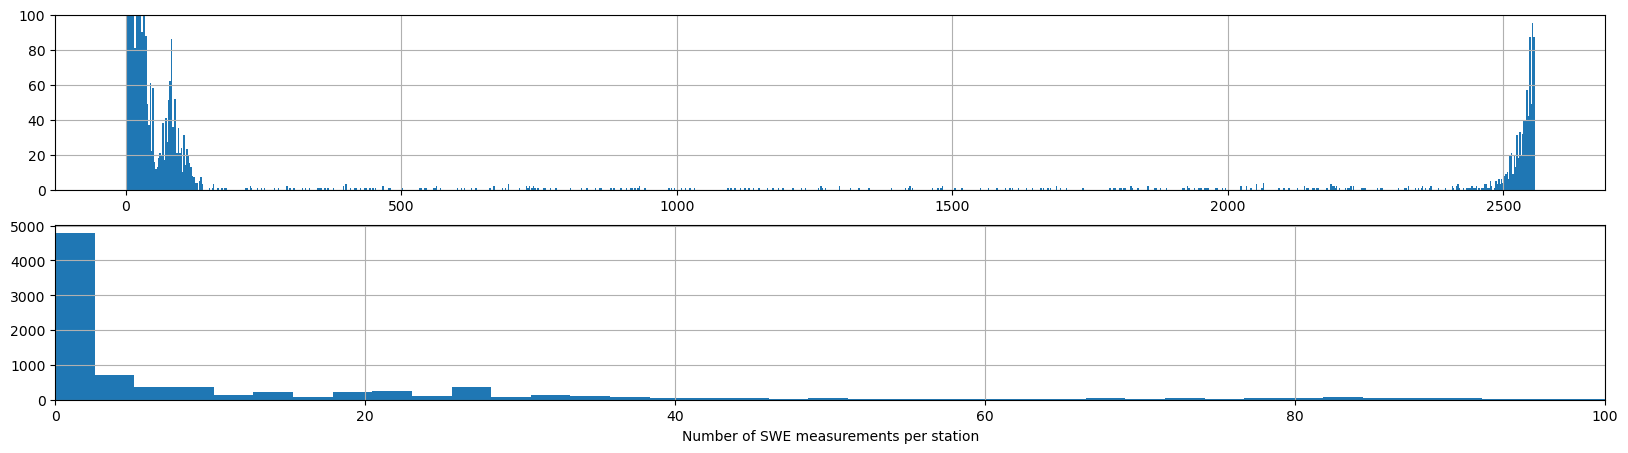

In [12]:
# make histogram of number of measurements per station
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 5))
NorSWE_station_counts['snw'].hist(bins=1000, ax=axs[0])
axs[0].set_ylim(0, 100)
axs[1].set_xlabel('Number of SWE measurements per station')
NorSWE_station_counts['snw'].hist(bins=1000, ax=axs[1])
axs[1].set_xlim(0, 100)
fig.savefig('figures/NorSWE_station_counts_histogram.png', dpi=300, bbox_inches='tight')

In [13]:
# what percent of stations have less than 10 measurements?
percent_less_than_10_measurements = (NorSWE_station_counts['snw'] < 10).sum() / len(NorSWE_station_counts) * 100
print(f"Percent of stations with less than 10 measurements: {percent_less_than_10_measurements:.2f}%")

Percent of stations with less than 10 measurements: 59.75%


# doesn't look like enough daily data :(

In [14]:
# os.environ['PLANET_API_KEY'] = ''

# def get_planet_basemap_from_gdf(gdf, mosaic_name="global_monthly_2025_08_mosaic", zoom="auto"):
#     api_key = os.environ["PLANET_API_KEY"]
#     url = f"https://tiles.planet.com/basemaps/v1/planet-tiles/{mosaic_name}/gmap/{{z}}/{{x}}/{{y}}.png?api_key={api_key}"

#     gdf_3857 = gdf.to_crs(epsg=3857)

#     img, extent = ctx.bounds2img(
#         *gdf_3857.total_bounds,
#         zoom=zoom,
#         source=url,
#         ll=False,
#     )

#     left, right, bottom, top = extent
#     h, w = img.shape[:2]

#     da = xr.DataArray(
#         np.moveaxis(img[:, :, :3], -1, 0).astype(np.float32),
#         dims=["band", "y", "x"],
#         coords={
#             "band": [1, 2, 3],
#             "y": np.linspace(top, bottom, h),
#             "x": np.linspace(left, right, w),
#         },
#     )
#     da = da.rio.write_crs("EPSG:3857")
#     da = da.rio.reproject(gdf.crs)
#     da = da.rio.clip(gdf.to_crs(gdf.crs).geometry, all_touched=True)
#     da.attrs["mosaic"] = mosaic_name

#     return da

# planet_da = get_planet_basemap_from_gdf(station_utm_gdf)
# planet_da

# f,ax=plt.subplots(figsize=(10,10))
# planet_da.plot.imshow(ax=ax,robust=True)
# ax.set_aspect('equal')
# ax.set_title(f"Planet {planet_da.attrs['mosaic']}")